# Part 1: Preprocessing — Making the Data Modellable
**⏱ This section takes approximately 30 minutes.**

---

## Scenario: Tuesday — Cleaning before Modelling

Sarah arrives Tuesday with two coffees and a plan.

Yesterday she opened the dataset. Today she has to turn it into something a model can actually train on. Three things stand between her and a usable training set:

- **Missing values** in `last_login_days_ago` (8%) and `avg_review_polarity` (30%)
- **Two text columns** (`region`, `subscription_tier`) that need to become numeric
- **Wildly different scales** — `age` is 18–80, `avg_monthly_spend_gbp` is 0–500, `returns_per_purchase` is 0.00–0.50

She doesn't want to do this by hand on every column. She wants ONE object — a pipeline — that does all three transformations in the right order, applies the same logic to new data, and never accidentally leaks information from the test set into training.

**By the end of this notebook you will be able to:**
- Split data into train/test BEFORE preprocessing (the leakage-prevention move)
- Build a sklearn `ColumnTransformer` that imputes, scales, and encodes in one step
- Apply that transformer to the training data and inspect the result
- Recognise why the pipeline IS the right unit of work (not the individual steps)

## The Preprocessing Roadmap

Before we write any code, here is the full sequence of steps — and the reason each one exists.

```
Raw Data (10 cols, some NaN, text, mixed scale)
         │
         ▼
┌─────────────────────────────────────────────────────┐
│  STEP 1 — Train / Test Split  (FIRST, always first) │
│  Reason: prevents leakage — test rows must never    │
│  influence what the preprocessor learns             │
└──────────────────────┬──────────────────────────────┘
                       │
         ┌─────────────┴──────────────┐
         ▼                            ▼
  Numerical columns             Categorical columns
  (age, spend, …)               (region, tier)
         │                            │
         ▼                            ▼
  ┌────────────────┐         ┌──────────────────────┐
  │ Impute         │         │ Impute               │
  │ (fill NaN with │         │ (fill NaN with most  │
  │  column median)│         │  frequent value)     │
  └───────┬────────┘         └──────────┬───────────┘
          │                             │
          ▼                             ▼
  ┌────────────────┐         ┌──────────────────────┐
  │ Scale          │         │ One-hot Encode       │
  │ (mean 0, std 1)│         │ (text → 0/1 columns) │
  └───────┬────────┘         └──────────┬───────────┘
          │                             │
          └──────────────┬──────────────┘
                         ▼
          Clean numeric matrix  (no NaN, no text,
          all features on a comparable scale)
                         │
                         ▼
                  → Model training (Notebook 03)
```

### Why does each step matter?

| Problem | Effect on the model | Fix |
|---|---|---|
| **Missing values** | Most sklearn models crash on NaN | **Imputation** — fill with a representative value |
| **Text / categories** | Models need numbers, not strings | **One-hot encoding** — represent each category as a 0/1 column |
| **Wildly different scales** | A feature ranging 0–500 can dominate a feature ranging 0–1, even if the 0–1 feature is more predictive | **Scaling** — put every feature on a comparable scale |

In [ ]:
# Setup — run this cell first
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 20)
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (11, 4.5)

print("✅ Libraries loaded — you're ready to go!")

✅ Libraries loaded — you're ready to go!


## Step 1 — Load the data and define X, y

`X` is the feature matrix — everything we'd use as input to the model. `y` is the target — the column we're trying to predict. We drop `customer_id` because it carries no predictive information.

In [ ]:
df = pd.read_csv("data/northstar_churn.csv")

# Separate features (X) from target (y)
y = df["churned"]
X = df.drop(columns=["customer_id", "churned"])

print(f"X shape: {X.shape}  (10,000 customers × 10 features)")
print(f"y shape: {y.shape}  (10,000 labels — 12% churners)")
print()
print("Feature columns:")
for col in X.columns:
    dtype = X[col].dtype
    print(f"  · {col:25s}  {dtype}")

X shape: (10000, 10)  (10,000 customers × 10 features)
y shape: (10000,)  (10,000 labels — 12% churners)

Feature columns:
  · age                        int64
  · tenure_months              int64
  · region                     str
  · subscription_tier          str
  · num_purchases_quarter      int64
  · avg_monthly_spend_gbp      float64
  · returns_per_purchase       float64
  · last_login_days_ago        float64
  · avg_review_polarity        float64
  · support_tickets_quarter    int64


## Step 2 — Split BEFORE preprocessing (the leakage rule)

The single most important rule in supervised ML:

> **Split the data into train and test FIRST. Then fit your preprocessing on the training data only.**

If you fit your scaler or imputer on the full dataset, the statistics include the test rows. At deployment time you wouldn't have access to future test data — so the score you'd get at deployment will be worse than the score you measured in the notebook. This is *leakage*.

`stratify=y` preserves the class proportion (88% stayed / 12% churned) in both splits.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,
    random_state=42,
)

print(f"Training set: {len(X_train):,} customers ({y_train.mean():.1%} churn rate)")
print(f"Test set:     {len(X_test):,} customers ({y_test.mean():.1%} churn rate)")
print()
print("Class balance is preserved in both splits because of stratify=y.")

Training set: 8,000 customers (12.0% churn rate)
Test set:     2,000 customers (11.9% churn rate)

Class balance is preserved in both splits because of stratify=y.


## Step 3 — Identify numerical vs categorical features

Different column types need different preprocessing. We split the column names into two lists and treat each list with its own mini-pipeline.

In [ ]:
numeric_features = [
    "age",
    "tenure_months",
    "num_purchases_quarter",
    "avg_monthly_spend_gbp",
    "returns_per_purchase",
    "last_login_days_ago",
    "avg_review_polarity",
    "support_tickets_quarter",
]
categorical_features = ["region", "subscription_tier"]

print("Numerical features (impute → scale):")
for c in numeric_features: print(f"  · {c}")
print()
print("Categorical features (impute → one-hot encode):")
for c in categorical_features: print(f"  · {c}")

Numerical features (impute → scale):
  · age
  · tenure_months
  · num_purchases_quarter
  · avg_monthly_spend_gbp
  · returns_per_purchase
  · last_login_days_ago
  · avg_review_polarity
  · support_tickets_quarter

Categorical features (impute → one-hot encode):
  · region
  · subscription_tier


## ⏸️ Pause and Predict

Before running the next cell, think:

- For the **numerical features**, we will impute missing values with the *median*. Why median (not mean) for this dataset?
- For the **categorical features**, we will one-hot encode. After encoding, `region` (6 unique values) becomes how many new columns?
- After all this preprocessing, what will the **total number of columns** be?

*Write your predictions here (double-click to edit):*

> *Sample answers (don't peek until you've thought about it):*
> - **Median over mean** — `avg_monthly_spend_gbp` is right-skewed (a few high-spenders). Median is robust to those outliers; mean would be pulled upward.
> - **One-hot expansion** — `region` (6 values) → 6 new columns. `subscription_tier` (3 values) → 3 new columns. Total new columns from encoding: 9.
> - **Final column count** — 8 numerical (unchanged) + 9 one-hot columns = 17 columns total.

## Step 4 — Build the ColumnTransformer

### What is one-hot encoding?

When a column contains text categories like `region = "London"`, a model can't use it directly — it needs numbers. **One-hot encoding** creates a separate 0/1 column for each unique value:

```
region = "London"    →   region_London=1, region_Ireland=0, region_North=0, …
region = "Ireland"   →   region_London=0, region_Ireland=1, region_North=0, …
```

This avoids the "invented order" problem — if we instead mapped London→1, Ireland→2, North→3, the model would falsely assume Ireland is *between* London and North in some meaningful way.

### Why ColumnTransformer?

Different column types need different transformations: numerical columns need imputation + scaling, while categorical columns need imputation + encoding. We *could* do each manually, but that creates three problems:

1. **Error-prone** — easy to apply the wrong step to the wrong column
2. **Leakage risk** — if you fit steps outside a pipeline you might accidentally fit on test data
3. **Not reusable** — in production you'd need to remember and repeat every step in the right order

`ColumnTransformer` solves all three: it routes each column to its appropriate mini-pipeline, fits on training data only, and can be saved and reapplied to new data as a single object.

### Three nested objects

1. The **`Pipeline`** for each column type — a list of steps applied in order.
2. The **`ColumnTransformer`** — applies the right pipeline to the right columns.
3. (We'll combine this with the model in notebook 03.)

In [ ]:
# Mini-pipeline for numerical columns
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler()),
])

# Mini-pipeline for categorical columns
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

# Combine into a single ColumnTransformer
preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features),
])

print("✅ Preprocessor built.")
print()
print("It will apply, in order:")
print("  Numerical columns:")
print("    1. SimpleImputer(strategy='median')   → fill NaN with column median")
print("    2. StandardScaler()                    → subtract mean, divide by std")
print()
print("  Categorical columns:")
print("    1. SimpleImputer(strategy='most_frequent')  → fill NaN with most common value")
print("    2. OneHotEncoder(handle_unknown='ignore')   → expand to 0/1 columns")

✅ Preprocessor built.

It will apply, in order:
  Numerical columns:
    1. SimpleImputer(strategy='median')   → fill NaN with column median
    2. StandardScaler()                    → subtract mean, divide by std

  Categorical columns:
    1. SimpleImputer(strategy='most_frequent')  → fill NaN with most common value
    2. OneHotEncoder(handle_unknown='ignore')   → expand to 0/1 columns


## Step 5 — Fit and transform the training data

The preprocessor learns its parameters (means, medians, category lists) from `X_train` and transforms it. The result is a clean numeric matrix — no NaN, no text, all features on a comparable scale.

In [ ]:
X_train_processed = preprocessor.fit_transform(X_train)

# Get the resulting column names (numeric names unchanged + one-hot columns named region_X, subscription_tier_X)
feature_names_out = preprocessor.get_feature_names_out()

print(f"Original X_train shape:    {X_train.shape}  ({X_train.shape[1]} columns)")
print(f"Processed X_train shape:   {X_train_processed.shape}  ({X_train_processed.shape[1]} columns)")
print()
print(f"Number of NaN values in processed array: {np.isnan(X_train_processed).sum()}")
print()
print("Final feature names:")
for name in feature_names_out:
    print(f"  · {name}")

Original X_train shape:    (8000, 10)  (10 columns)
Processed X_train shape:   (8000, 17)  (17 columns)

Number of NaN values in processed array: 0

Final feature names:
  · num__age
  · num__tenure_months
  · num__num_purchases_quarter
  · num__avg_monthly_spend_gbp
  · num__returns_per_purchase
  · num__last_login_days_ago
  · num__avg_review_polarity
  · num__support_tickets_quarter
  · cat__region_Ireland
  · cat__region_London
  · cat__region_North
  · cat__region_Scotland
  · cat__region_South
  · cat__region_Wales
  · cat__subscription_tier_basic
  · cat__subscription_tier_free
  · cat__subscription_tier_premium


### 💡 What you should notice

- **Column count grew from 10 to 17.** The 6-value `region` expanded to 6 binary columns; the 3-value `subscription_tier` expanded to 3. (8 + 6 + 3 = 17.)
- **No NaN remain.** Every missing value was filled before scaling/encoding.
- **The numerical columns are now scaled** — their values are roughly centred on 0 with standard deviation 1.

Let's verify the scaling by checking the mean and std of one numeric column before and after.

In [ ]:
# Show the effect of scaling for one column — avg_monthly_spend_gbp
col_idx = list(feature_names_out).index("num__avg_monthly_spend_gbp")

before = X_train["avg_monthly_spend_gbp"].dropna()
after  = X_train_processed[:, col_idx]

print(f"Before scaling — avg_monthly_spend_gbp:")
print(f"  mean: {before.mean():7.2f}     std: {before.std():7.2f}")
print(f"  min:  {before.min():7.2f}     max: {before.max():7.2f}")
print()
print(f"After scaling — num__avg_monthly_spend_gbp:")
print(f"  mean: {after.mean():7.2f}     std: {after.std():7.2f}")
print(f"  min:  {after.min():7.2f}     max: {after.max():7.2f}")
print()
print("→ Centred on 0, std ≈ 1. The original distribution shape is preserved, only the scale changed.")

Before scaling — avg_monthly_spend_gbp:
  mean:   69.88     std:   55.73
  min:     4.66     max:  500.00

After scaling — num__avg_monthly_spend_gbp:
  mean:   -0.00     std:    1.00
  min:    -1.17     max:    7.72

→ Centred on 0, std ≈ 1. The original distribution shape is preserved, only the scale changed.


## ✅ Section Summary

| Step | What it does | sklearn class |
|---|---|---|
| **1. Split first** | Hold out 20% as a test set BEFORE fitting any preprocessing | `train_test_split(stratify=y)` |
| **2. Median impute** | Fill numerical NaN with the column median (robust to outliers) | `SimpleImputer(strategy="median")` |
| **3. Standard scale** | Centre each numeric column on 0, std 1 | `StandardScaler()` |
| **4. Mode impute** | Fill categorical NaN with the most common value | `SimpleImputer(strategy="most_frequent")` |
| **5. One-hot encode** | Expand each categorical to binary columns | `OneHotEncoder(handle_unknown="ignore")` |
| **6. ColumnTransformer** | Apply different pipelines to different column sets | `ColumnTransformer([("num", ...), ("cat", ...)])` |

**Key insight for our scenario:**
> Sarah now has ONE object — `preprocessor` — that handles the entire cleaning step. She'll use this in tomorrow's notebook to chain preprocessing + model into a single fittable, reusable, deployable pipeline.

---
**Up next → Part 2:** Wednesday — Sarah trains her first logistic regression on the preprocessed data, inspects the coefficients, and uses k-fold cross-validation to get a stable accuracy estimate.
Open `03_train_validate.ipynb`

---

## 🟡 Extension — self-study after class

*Skipping this section will not affect your understanding of later lessons. Come back to it when you have time and want to go deeper.*

## Extension 1 — Why median over mean?

`avg_monthly_spend_gbp` is right-skewed. A few high-spenders pull the mean upward. The median is much closer to the "typical" value.

If we'd used the mean to impute missing values, we'd be replacing missing values with a value HIGHER than most of the actual data — biasing the model upward for those rows. Median imputation avoids this.

<<<<<<< local


Mean spend:   £69.88
Median spend: £54.17
Gap:          £15.71



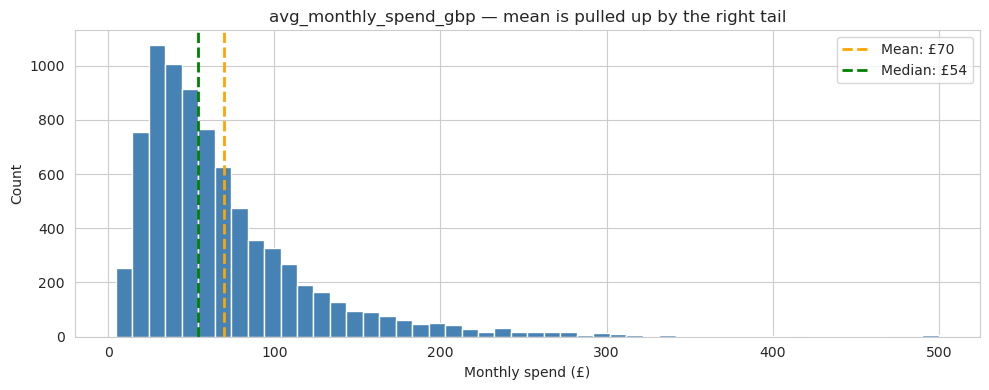

Mean spend:   £69.88
Median spend: £54.17
Gap:          £15.71



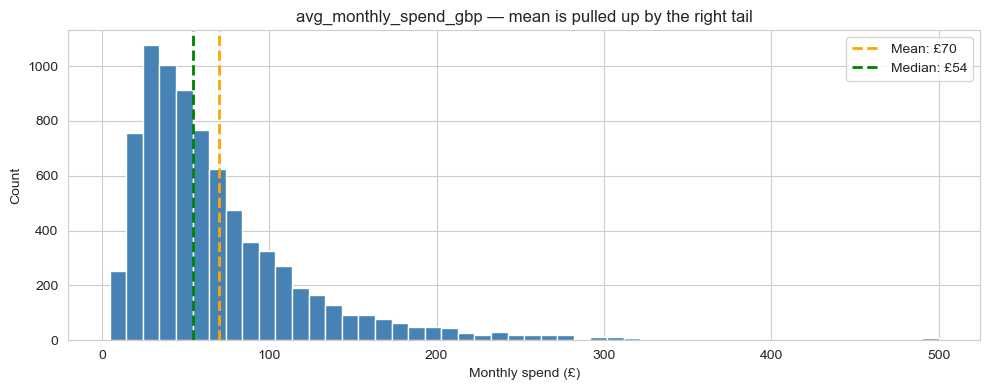

>>>>>>> remote


In [ ]:
# Compare mean vs median imputation for a skewed column
spend = X_train["avg_monthly_spend_gbp"]

print(f"Mean spend:   £{spend.mean():.2f}")
print(f"Median spend: £{spend.median():.2f}")
print(f"Gap:          £{spend.mean() - spend.median():.2f}")
print()

# Plot
fig, ax = plt.subplots(figsize=(10, 4))
spend.hist(bins=50, color="steelblue", edgecolor="white", ax=ax)
ax.axvline(spend.mean(),   color="orange",  linewidth=2, linestyle="--", label=f"Mean: £{spend.mean():.0f}")
ax.axvline(spend.median(), color="green",   linewidth=2, linestyle="--", label=f"Median: £{spend.median():.0f}")
ax.set_xlabel("Monthly spend (£)")
ax.set_ylabel("Count")
ax.set_title("avg_monthly_spend_gbp — mean is pulled up by the right tail")
ax.legend()
plt.tight_layout()
plt.show()

## Extension 2 — Adding a "was-missing" indicator

> **Note:** This technique was introduced in the pre-class reading (the interactive diagram in `docs/index.html`). This extension shows the sklearn implementation so you can see how it works in code.

For `avg_review_polarity` (30% missing), the missingness itself is informative — customers who don't leave reviews behave differently from those who do. A model can benefit from knowing *which* rows were originally missing.

We can add a binary `was_missing` flag alongside the imputed value using `SimpleImputer(add_indicator=True)`. This keeps both signals: the filled-in value **and** a 0/1 column that marks rows that were originally NaN.

In [ ]:
from sklearn.impute import SimpleImputer

# Imputer that ALSO returns a "was missing" indicator column
imputer_with_flag = SimpleImputer(strategy="median", add_indicator=True)

review_col = X_train[["avg_review_polarity"]]
imputed = imputer_with_flag.fit_transform(review_col)

print(f"Input shape:  {review_col.shape}  (1 column)")
print(f"Output shape: {imputed.shape}  (2 columns — imputed value + was-missing flag)")
print()

# Show a few rows with the flag set
df_demo = pd.DataFrame(imputed, columns=["polarity_imputed", "was_missing"],
                       index=review_col.index)
df_demo["original"] = review_col["avg_review_polarity"]
print("Sample rows (some were originally missing, some weren't):")
print(df_demo[df_demo["was_missing"] == 1].head(3).round(3).to_string())
print()
print(df_demo[df_demo["was_missing"] == 0].head(3).round(3).to_string())

Input shape:  (8000, 1)  (1 column)
Output shape: (8000, 2)  (2 columns — imputed value + was-missing flag)

Sample rows (some were originally missing, some weren't):
      polarity_imputed  was_missing  original
9265             0.147          1.0       NaN
4532             0.147          1.0       NaN
131              0.147          1.0       NaN

      polarity_imputed  was_missing  original
2910             0.415          0.0     0.415
4590             0.215          0.0     0.215
6226             0.397          0.0     0.397


## Extension 3 — Different scalers: Standard vs MinMax vs Robust

`StandardScaler` is the default for logistic regression. But there are alternatives.

| Scaler | What it does | When to use |
|---|---|---|
| `StandardScaler` | Subtract mean, divide by std → mean 0, std 1 | Default. Most algorithms. |
| `MinMaxScaler` | Map to [0, 1] | When you need bounded output (e.g., neural networks with sigmoid activations) |
| `RobustScaler` | Subtract median, divide by IQR | When you have heavy outliers that distort the mean and std |

<<<<<<< local


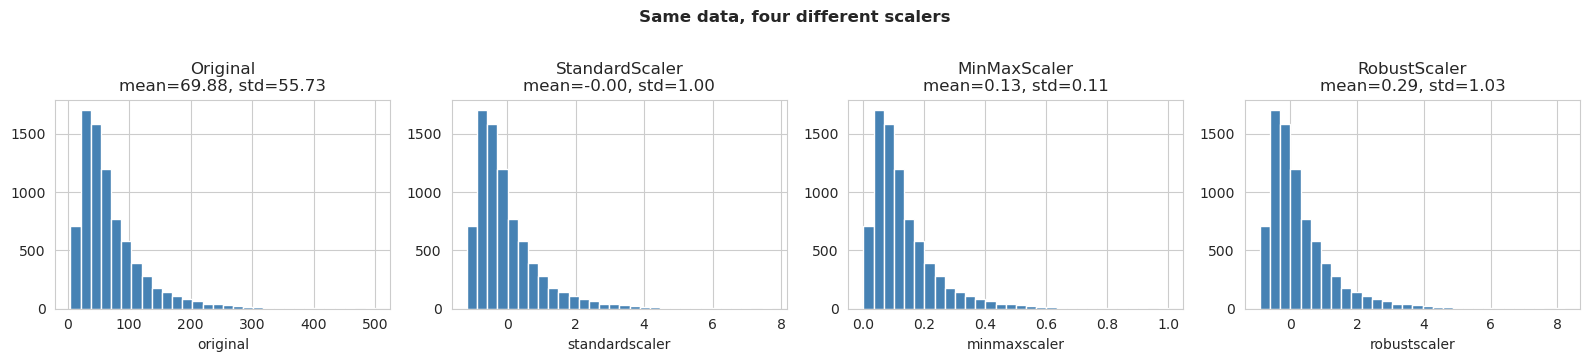

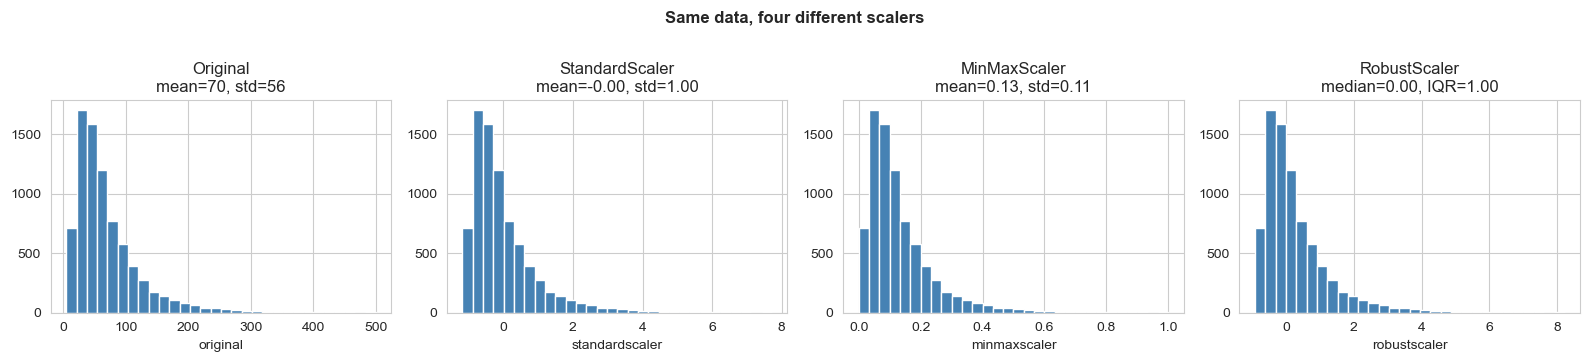

>>>>>>> remote


In [ ]:
from sklearn.preprocessing import MinMaxScaler, RobustScaler
import numpy as np

# Compare all three on avg_monthly_spend_gbp
spend = X_train[["avg_monthly_spend_gbp"]]

scalers = {
    "Original":       None,
    "StandardScaler": StandardScaler(),
    "MinMaxScaler":   MinMaxScaler(),
    "RobustScaler":   RobustScaler(),
}

fig, axes = plt.subplots(1, 4, figsize=(16, 3.5))
for ax, (name, scaler) in zip(axes, scalers.items()):
    if scaler is None:
        vals = spend.values.ravel()
        subtitle = f"mean={vals.mean():.0f}, std={vals.std():.0f}"
    else:
        vals = scaler.fit_transform(spend).ravel()
        if isinstance(scaler, RobustScaler):
            q25, q75 = np.percentile(vals, 25), np.percentile(vals, 75)
            subtitle = f"median={np.median(vals):.2f}, IQR={q75 - q25:.2f}"
        else:
            subtitle = f"mean={vals.mean():.2f}, std={vals.std():.2f}"
    ax.hist(vals, bins=30, color="steelblue", edgecolor="white")
    ax.set_title(f"{name}\n{subtitle}")
    ax.set_xlabel(name.lower())
plt.suptitle("Same data, four different scalers", y=1.02, fontweight="bold")
plt.tight_layout()
plt.show()

### 💡 What this tells us

- **StandardScaler** and **RobustScaler** look similar here but the latter is less affected by the high-spending outliers (notice the centre is at 0 in both, but RobustScaler's spread reflects the inter-quartile range rather than the std).
- **MinMaxScaler** crushes everything below £150 into the lower 30% of the range — because the few outliers near £500 stretch the upper end.

For logistic regression on this dataset, `StandardScaler` is the right default. If your dataset had very extreme outliers (say a single £100,000-spending customer), switch to `RobustScaler`.